In [ ]:
# Heart Disease Prediction Using Machine Learning

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [3]:
df = pd.read_csv('heart.csv')

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.shape

(1025, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [6]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.duplicated().sum()

np.int64(723)

In [9]:
df = df.drop_duplicates()

In [10]:
X = df.drop('target', axis=1)

y = df['target']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

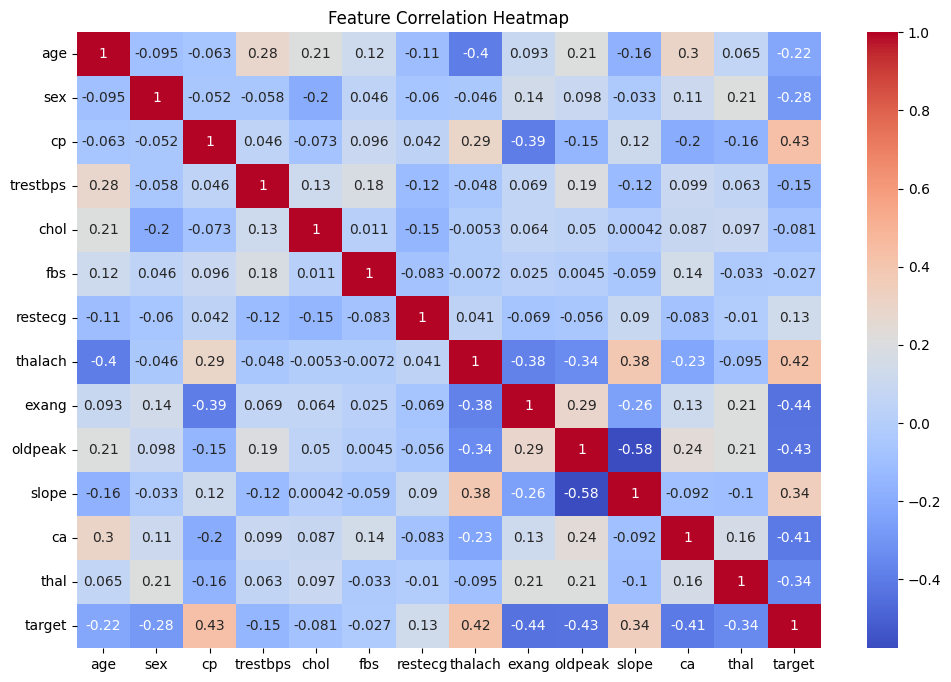

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [13]:
corr = df.corr()['target'].sort_values(ascending=False)

print(corr)

target      1.000000
cp          0.432080
thalach     0.419955
slope       0.343940
restecg     0.134874
fbs        -0.026826
chol       -0.081437
trestbps   -0.146269
age        -0.221476
sex        -0.283609
thal       -0.343101
ca         -0.408992
oldpeak    -0.429146
exang      -0.435601
Name: target, dtype: float64


Features such as cp, thalach and slope show strong positive correlation with heart disease prediction, while exang and oldpeak show negative correlation. Therefore, these features are important predictors.


In [14]:
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

log_acc = accuracy_score(y_test, log_pred)
log_pre = precision_score(y_test, log_pred)
log_rec = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)

print("Accuracy:", log_acc)
print("Precision:", log_pre)
print("Recall:", log_rec)
print("F1 Score:", log_f1)

Accuracy: 0.7868852459016393
Precision: 0.7222222222222222
Recall: 0.896551724137931
F1 Score: 0.8


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_pre = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Accuracy:", rf_acc)
print("Precision:", rf_pre)
print("Recall:", rf_rec)
print("F1 Score:", rf_f1)

Accuracy: 0.8360655737704918
Precision: 0.7878787878787878
Recall: 0.896551724137931
F1 Score: 0.8387096774193549


In [16]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)
knn_pre = precision_score(y_test, knn_pred)
knn_rec = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

print("Accuracy:", knn_acc)
print("Precision:", knn_pre)
print("Recall:", knn_rec)
print("F1 Score:", knn_f1)

Accuracy: 0.639344262295082
Precision: 0.5813953488372093
Recall: 0.8620689655172413
F1 Score: 0.6944444444444444


In [17]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'KNN'
    ],
    'Accuracy': [
        log_acc,
        rf_acc,
        knn_acc
    ],
    'Precision': [
        log_pre,
        rf_pre,
        knn_pre
    ],
    'Recall': [
        log_rec,
        rf_rec,
        knn_rec
    ],
    'F1 Score': [
        log_f1,
        rf_f1,
        knn_f1
    ]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.836066,0.787879,0.896552,0.838710
0,Logistic Regression,0.786885,0.722222,0.896552,0.800000
2,KNN,0.639344,0.581395,0.862069,0.694444


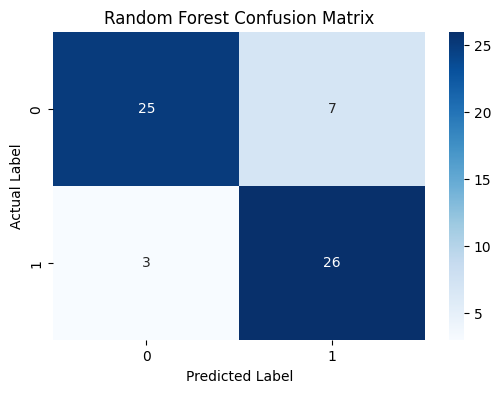

In [18]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

The confusion matrix indicates that the Random Forest model correctly classified most instances of both heart disease and non-heart disease cases. The number of false predictions is relatively low, supporting the model's strong overall accuracy and reliability.

Among the three machine learning algorithms tested, Random Forest achieved the highest accuracy of 83.61% and an F1-score of 83.87%. It outperformed Logistic Regression and KNN in overall classification performance. The model demonstrated strong recall (89.66%), indicating its ability to correctly identify patients with heart disease. Random Forest can capture complex relationships between features and reduce overfitting through ensemble learning. Therefore, Random Forest was selected as the best-performing model for heart disease prediction.

This project focused on predicting heart disease using machine learning techniques. The dataset was preprocessed, analyzed, and divided into training and testing sets. Three classification models—Logistic Regression, Random Forest, and KNN—were trained and evaluated using Accuracy, Precision, Recall, and F1 Score. Random Forest achieved the highest accuracy of 83.61%, making it the best-performing model. The results show that machine learning can be effectively used to support heart disease prediction and healthcare decision-making.